<a href="https://colab.research.google.com/github/Chandukasaraju/Udbhavathon_seg/blob/main/Offroad_Segmentation_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Untitled folder', 'Untitled document.gdoc', 'harika']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/harika'))

['train', 'val']


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/harika"

TRAIN_IMG_DIR = DATASET_ROOT + "/train/Color_Images"
TRAIN_MASK_DIR = DATASET_ROOT + "/train/Segmentation"
VAL_IMG_DIR = DATASET_ROOT + "/val/Color_Images"
VAL_MASK_DIR = DATASET_ROOT + "/val/Segmentation"

print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TRAIN_MASK_DIR:", TRAIN_MASK_DIR)
print("VAL_IMG_DIR:", VAL_IMG_DIR)
print("VAL_MASK_DIR:", VAL_MASK_DIR)

DATASET_ROOT: /content/drive/MyDrive/harika
TRAIN_IMG_DIR: /content/drive/MyDrive/harika/train/Color_Images
TRAIN_MASK_DIR: /content/drive/MyDrive/harika/train/Segmentation
VAL_IMG_DIR: /content/drive/MyDrive/harika/val/Color_Images
VAL_MASK_DIR: /content/drive/MyDrive/harika/val/Segmentation


In [ ]:
print("DATASET_ROOT exists:", os.path.exists(DATASET_ROOT))
print("TRAIN_IMG_DIR exists:", os.path.exists(TRAIN_IMG_DIR))
print("TRAIN_MASK_DIR exists:", os.path.exists(TRAIN_MASK_DIR))
print("VAL_IMG_DIR exists:", os.path.exists(VAL_IMG_DIR))
print("VAL_MASK_DIR exists:", os.path.exists(VAL_MASK_DIR))

DATASET_ROOT exists: True
TRAIN_IMG_DIR exists: True
TRAIN_MASK_DIR exists: True
VAL_IMG_DIR exists: True
VAL_MASK_DIR exists: True


In [ ]:
print("Train Images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Train Masks :", len(os.listdir(TRAIN_MASK_DIR)))
print("Val Images  :", len(os.listdir(VAL_IMG_DIR)))
print("Val Masks   :", len(os.listdir(VAL_MASK_DIR)))

Train Images: 2857
Train Masks : 2857
Val Images  : 317
Val Masks   : 317


In [ ]:
print("Train image files:", sorted(os.listdir(TRAIN_IMG_DIR))[:5])
print("Train mask files :", sorted(os.listdir(TRAIN_MASK_DIR))[:5])
print("Val image files  :", sorted(os.listdir(VAL_IMG_DIR))[:5])
print("Val mask files   :", sorted(os.listdir(VAL_MASK_DIR))[:5])

Train image files: ['cc0000012.png', 'cc0000013.png', 'cc0000014.png', 'cc0000015.png', 'cc0000017.png']
Train mask files : ['cc0000012.png', 'cc0000013.png', 'cc0000014.png', 'cc0000015.png', 'cc0000017.png']
Val image files  : ['cc0000016.png', 'cc0000019.png', 'cc0000020.png', 'cc0000024.png', 'cc0000032.png']
Val mask files   : ['cc0000016.png', 'cc0000019.png', 'cc0000020.png', 'cc0000024.png', 'cc0000032.png']


Sample image path: /content/drive/MyDrive/harika/train/Color_Images/cc0000012.png
Sample mask path : /content/drive/MyDrive/harika/train/Segmentation/cc0000012.png
Image shape: (540, 960, 3)
Mask shape : (540, 960)
Mask unique values: [ 0  1  2  3 27 39]


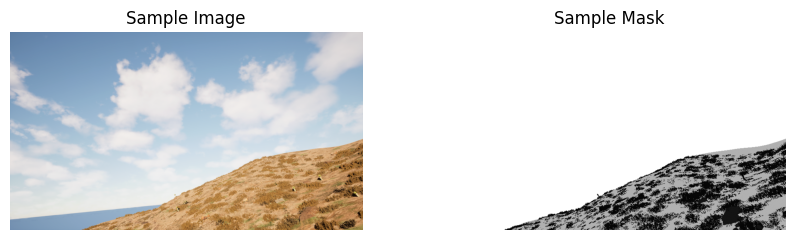

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sample_img_path = os.path.join(TRAIN_IMG_DIR, sorted(os.listdir(TRAIN_IMG_DIR))[0])
sample_mask_path = os.path.join(TRAIN_MASK_DIR, sorted(os.listdir(TRAIN_MASK_DIR))[0])

print("Sample image path:", sample_img_path)
print("Sample mask path :", sample_mask_path)

img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)
print("Mask unique values:", np.unique(mask)[:20])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Sample Mask")
plt.axis("off")

plt.show()

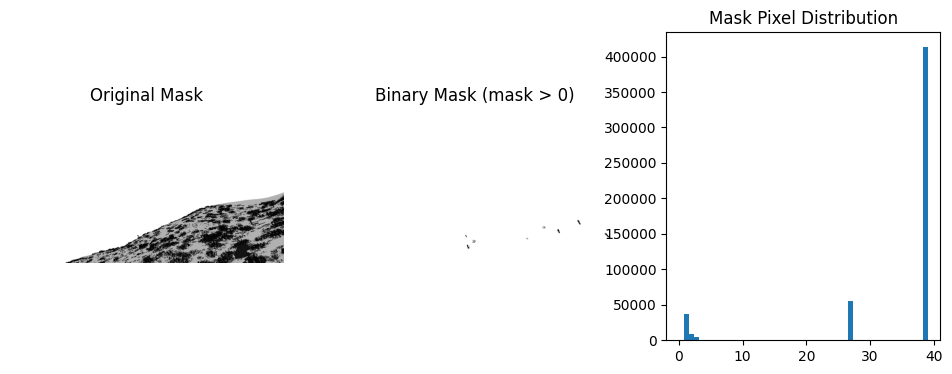

Original unique values: [ 0  1  2  3 27 39]
Binary unique values: [0 1]


In [ ]:
sample_mask_path = os.path.join(TRAIN_MASK_DIR, sorted(os.listdir(TRAIN_MASK_DIR))[0])

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)
binary_mask = (mask > 0).astype(np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Mask (mask > 0)")
plt.axis("off")

plt.subplot(1,3,3)
plt.hist(mask.flatten(), bins=50)
plt.title("Mask Pixel Distribution")

plt.show()

print("Original unique values:", np.unique(mask))
print("Binary unique values:", np.unique(binary_mask))

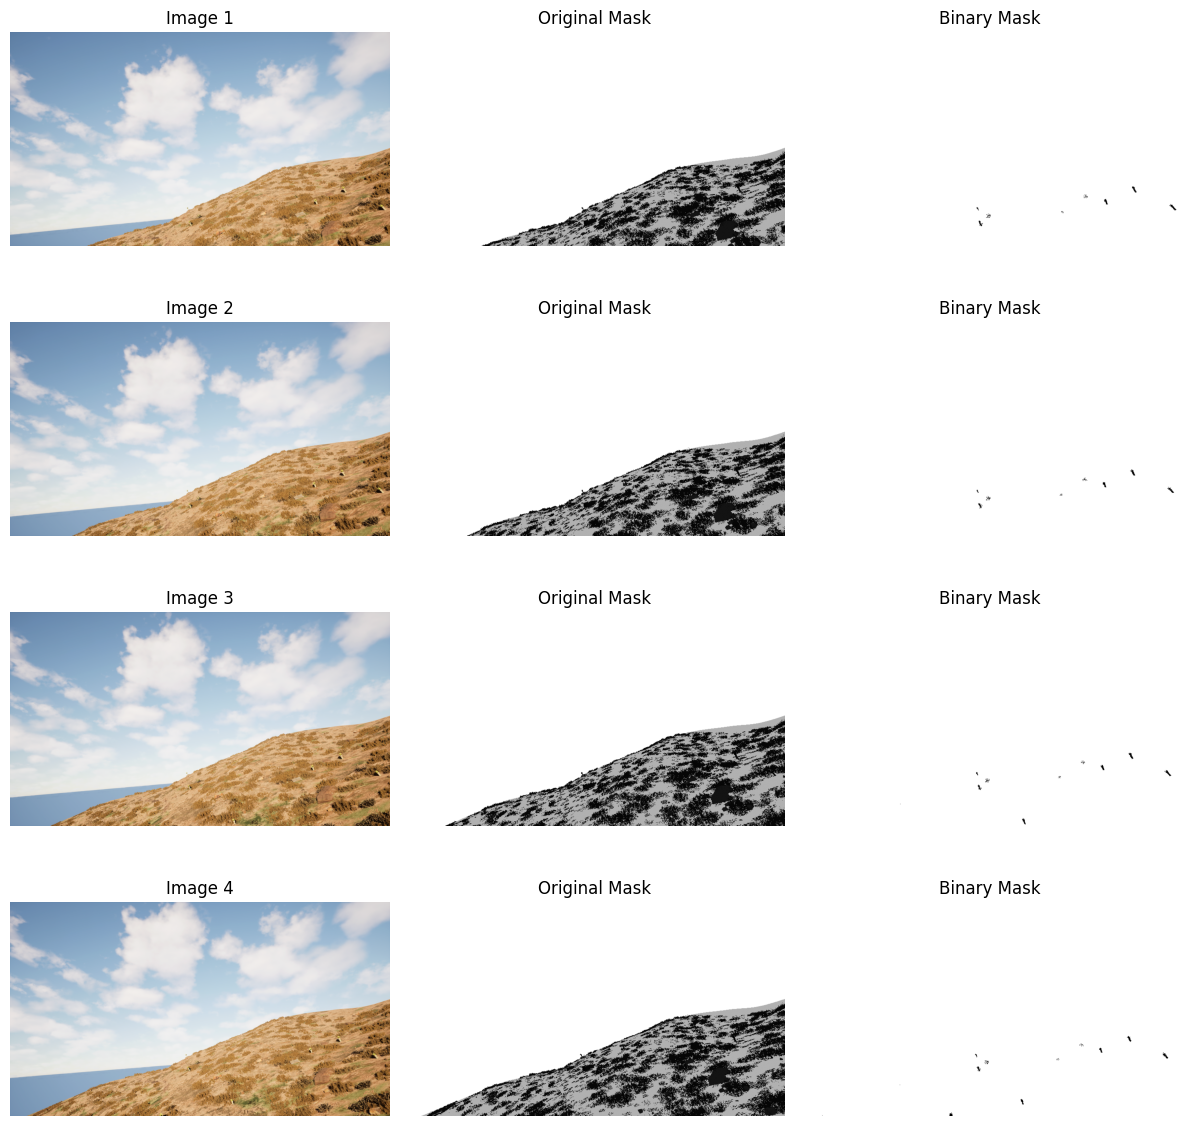

In [ ]:
sample_files = sorted(os.listdir(TRAIN_IMG_DIR))[:4]

plt.figure(figsize=(12,12))

for i, fname in enumerate(sample_files):
    img_path = os.path.join(TRAIN_IMG_DIR, fname)
    mask_path = os.path.join(TRAIN_MASK_DIR, fname)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    binary_mask = (mask > 0).astype(np.uint8)

    plt.subplot(4,3,i*3+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    plt.subplot(4,3,i*3+2)
    plt.imshow(mask, cmap="gray")
    plt.title("Original Mask")
    plt.axis("off")

    plt.subplot(4,3,i*3+3)
    plt.imshow(binary_mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
Device: cuda


In [ ]:
!pip install -q segmentation-models-pytorch

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

In [ ]:
class OffroadDataset(Dataset):
    def __init__(self, img_dir, mask_dir, image_size=(256, 256)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.image_size = image_size

        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        self.valid_images = []
        for f in self.images:
            if os.path.exists(os.path.join(mask_dir, f)):
                self.valid_images.append(f)

        print(f"Loaded {len(self.valid_images)} matched files from {img_dir}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        file_name = self.valid_images[idx]

        img_path = os.path.join(self.img_dir, file_name)
        mask_path = os.path.join(self.mask_dir, file_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # resize
        image = cv2.resize(image, self.image_size)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)

        # binary mask
        mask = (mask > 0).astype(np.float32)

        # normalize image
        image = image.astype(np.float32) / 255.0

        # HWC -> CHW
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [ ]:
train_dataset = OffroadDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, image_size=(320, 320))
val_dataset = OffroadDataset(VAL_IMG_DIR, VAL_MASK_DIR, image_size=(320, 320))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, drop_last=False)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

Loaded 2857 matched files from /content/drive/MyDrive/harika/train/Color_Images
Loaded 317 matched files from /content/drive/MyDrive/harika/val/Color_Images
Train dataset size: 2857
Val dataset size: 317


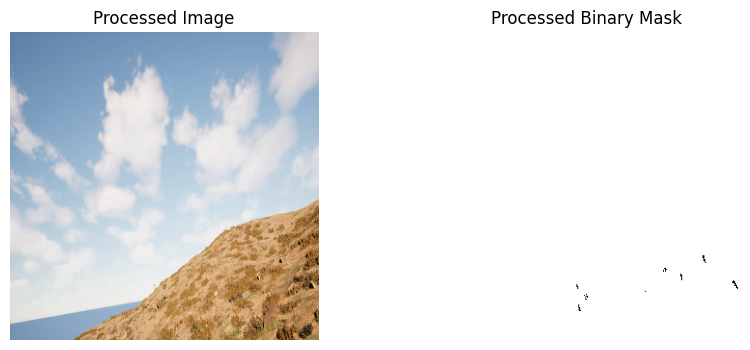

Processed mask unique values: [0. 1.]
Image tensor shape: torch.Size([3, 320, 320])
Mask tensor shape: torch.Size([1, 320, 320])


In [ ]:
image, mask = train_dataset[0]

img_np = image.permute(1, 2, 0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Processed Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Processed Binary Mask")
plt.axis("off")

plt.show()

print("Processed mask unique values:", np.unique(mask_np))
print("Image tensor shape:", image.shape)
print("Mask tensor shape:", mask.shape)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

print("Model loaded on:", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded on: cuda


In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

In [ ]:
def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

In [ ]:
num_epochs = 20
best_val_iou = 0.0
save_path = "/content/drive/MyDrive/harika/best_offroad_model.pth"

train_losses = []
val_ious = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            iou = compute_iou(outputs, masks)
            total_iou += iou

    avg_val_iou = total_iou / len(val_loader)
    val_ious.append(avg_val_iou)

    scheduler.step(avg_val_iou)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val IoU   : {avg_val_iou:.4f}")

    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved with IoU: {best_val_iou:.4f}")

Epoch 1/20 - Validation: 100%|██████████| 40/40 [02:25<00:00,  3.63s/it]



Epoch 1/20
Train Loss: 0.1906
Val IoU   : 0.9429
Best model saved with IoU: 0.9429


Epoch 2/20 - Validation: 100%|██████████| 40/40 [00:10<00:00,  3.77it/s]



Epoch 2/20
Train Loss: 0.0818
Val IoU   : 0.9549
Best model saved with IoU: 0.9549


Epoch 3/20 - Validation: 100%|██████████| 40/40 [00:10<00:00,  3.76it/s]


...


Epoch 18/20
Train Loss: 0.0418
Val IoU   : 0.9656
Best model saved with IoU: 0.9656


Epoch 19/20 - Validation: 100%|██████████| 40/40 [00:09<00:00,  4.33it/s]



Epoch 19/20
Train Loss: 0.0495
Val IoU   : 0.9648


Epoch 20/20 - Validation: 100%|██████████| 40/40 [00:11<00:00,  3.58it/s]


Epoch 20/20
Train Loss: 0.0432
Val IoU   : 0.9653


In [ ]:
print("Best Validation IoU:", best_val_iou)

Best Validation IoU: 0.9655769631266594


In [ ]:
import os

save_path = "/content/drive/MyDrive/harika/best_offroad_model.pth"
print("Model file exists:", os.path.exists(save_path))
print("Saved model path:", save_path)

Model file exists: True
Saved model path: /content/drive/MyDrive/harika/best_offroad_model.pth


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

print("Best model loaded successfully")

Best model loaded successfully


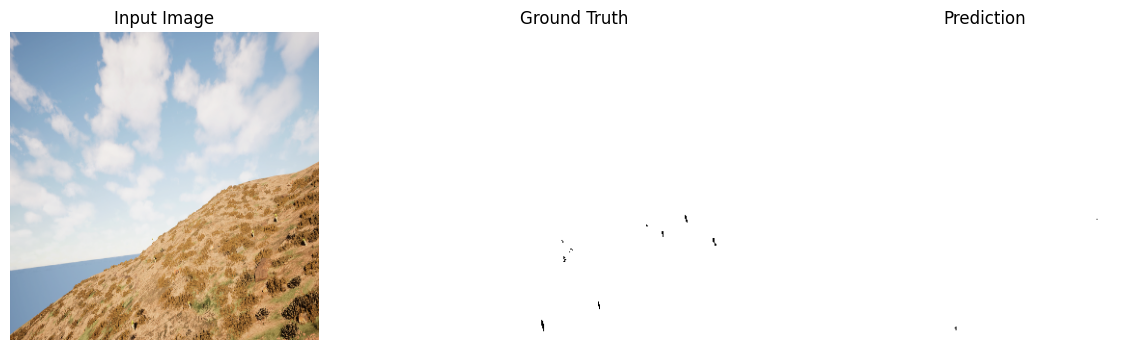

In [ ]:
image, mask = val_dataset[0]
input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    pred = torch.sigmoid(output).squeeze().cpu().numpy()
    pred = (pred > 0.5).astype(np.uint8)

img_np = image.permute(1, 2, 0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

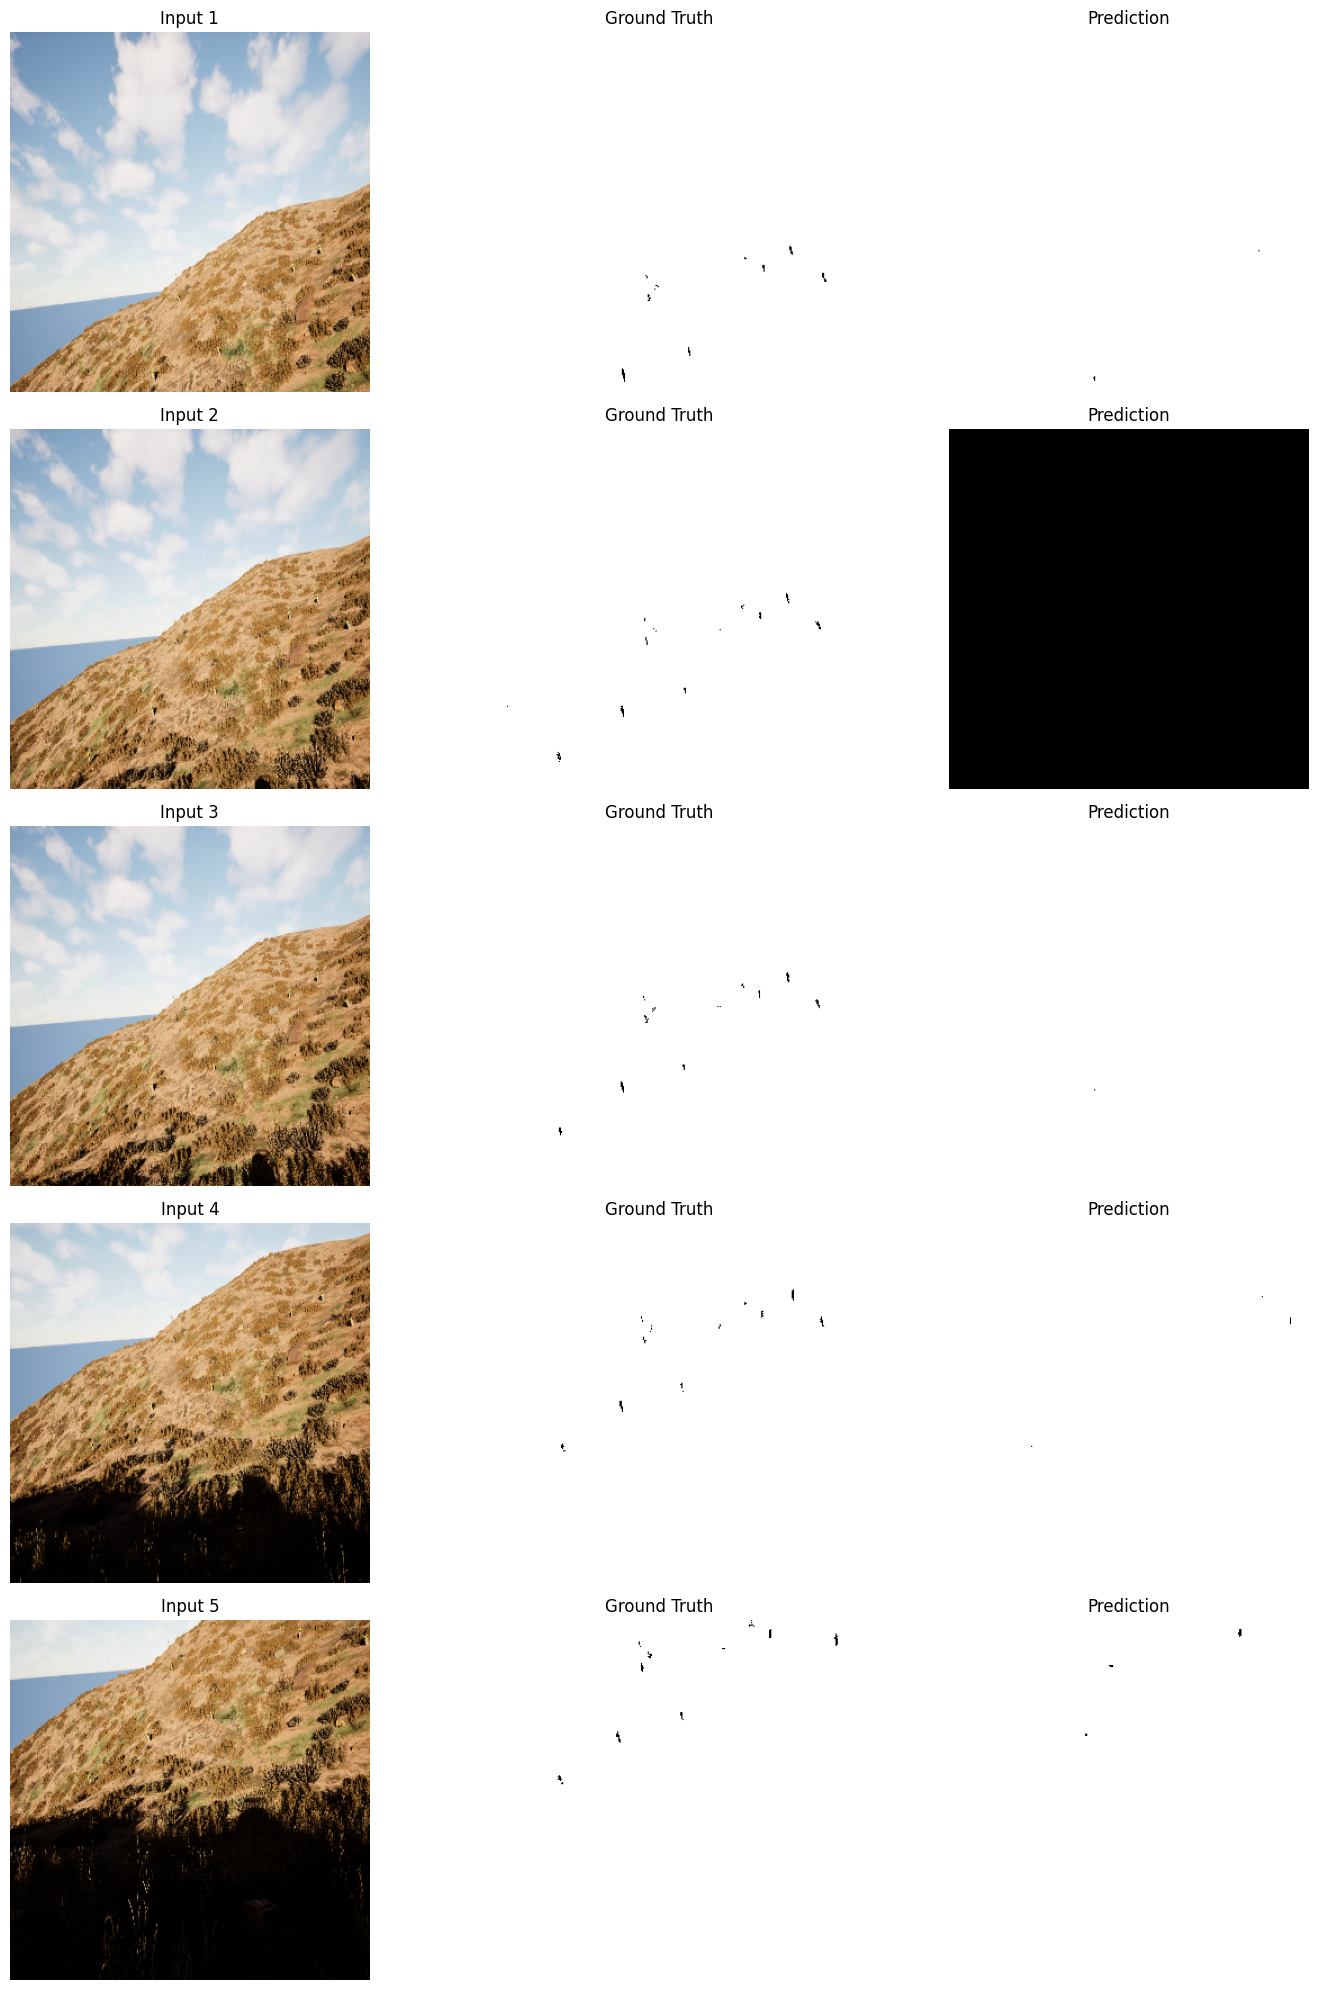

In [ ]:
num_samples = 5

plt.figure(figsize=(15, num_samples * 4))

for i in range(num_samples):
    image, mask = val_dataset[i]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.sigmoid(output).squeeze().cpu().numpy()
        pred = (pred > 0.5).astype(np.uint8)

    img_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()

    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(f"Input {i+1}")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

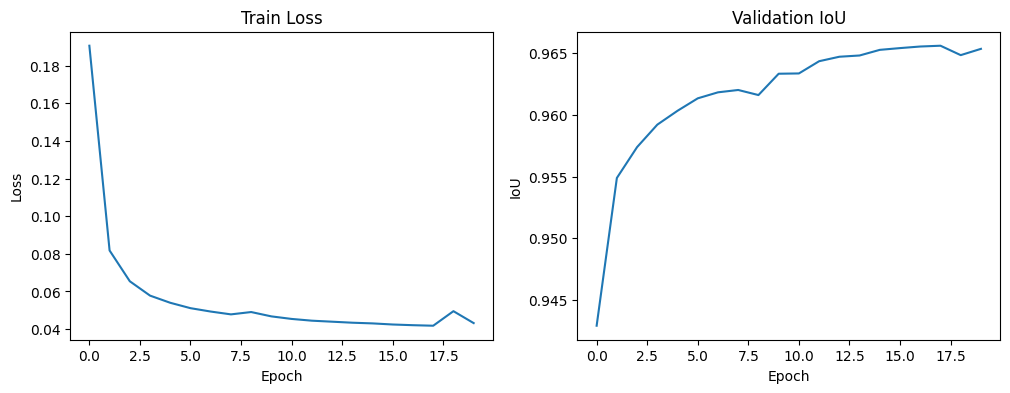

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(val_ious)
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.show()

In [ ]:
print("FINAL RESULT SUMMARY")
print("Model: DeepLabV3+")
print("Encoder: ResNet34")
print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Best Validation IoU:", best_val_iou)

FINAL RESULT SUMMARY
Model: DeepLabV3+
Encoder: ResNet34
Train Images: 2857
Validation Images: 317
Best Validation IoU: 0.9655769631266594


In [ ]:
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

total_iou = 0.0
num_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        iou = compute_iou(outputs, masks)

        total_iou += iou
        num_batches += 1

average_iou = total_iou / num_batches
print("Average IoU on Validation Set:", average_iou)
print("Average IoU Percentage:", average_iou * 100)

Average IoU on Validation Set: 0.9655769631266594
Average IoU Percentage: 96.55769631266594
